In [12]:
import requests
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
import random

# 1. API 요청 URL 및 파라미터 설정
url = 'https://apis.data.go.kr/1613000/RTMSDataSvcAptTradeDev/getRTMSDataSvcAptTradeDev'
# 본인의 발급받은 Decoding 키를 입력하세요.
service_key = '91b89db582a8b4e32560db475314eadfb1d2cd6aa256a914a381aa06e0d7cb4e' 

params = {
'serviceKey': service_key ,
'pageNo':'1', 
'numOfRows':'100',
'LAWD_CD':'11110',
'DEAL_YMD':'202312'
    
}

# 2. API 요청 및 응답 확인
response = requests.get( url, params=params )
root = ET.fromstring(response.content)

# 3. XML 데이터를 데이터프레임으로 변환
rng = np.random.default_rng(42)
data_list = []
for item in root.findall('.//item'):
    data = {
        'Transaction_Date': item.find('dealYear').text + 
                            item.find('dealMonth').text.zfill(2) + 
                            item.find('dealDay').text.zfill(2) ,
        'dealAmount' : item.find('dealAmount').text 
                        if item.find('dealAmount') is not None else None,
        'excluUseAr' : item.find('excluUseAr').text
                        if item.find('excluUseAr') is not None else None,
        'floor' : item.find('floor').text
                        if item.find('floor') is not None else None,
        'buildYear' : item.find('buildYear').text
                        if item.find('buildYear') is not None else None, 
        'Location' : rng.choice(['서울', '광주', '대전', '대구', '제주']) 
    # '서울', '광주', '대전', '대구', '제주' 5개 지역 중에서 랜덤
    }
    data_list.append(data)

df_api = pd.DataFrame(data_list)
df_api.head()


,Transaction_Date,dealAmount,excluUseAr,floor,buildYear,Location
0,20231226,"102,000",45.879,16,2017,서울
1,20231228,"102,000",45.879,16,2017,대구
2,20231230,"10,800",16.67,9,2012,대구
3,20231227,"194,000",84.8359,8,2017,대전
4,20231222,"128,000",59.6737,9,2019,대전


In [2]:
response.content

b'<?xml version="1.0" encoding="utf-8" standalone="yes"?><response><header><resultCode>000</resultCode><resultMsg>OK</resultMsg></header><body><items><item><aptDong>402</aptDong><aptNm>\xea\xb2\xbd\xed\x9d\xac\xea\xb6\x81\xec\x9e\x90\xec\x9d\xb4(4\xeb\x8b\xa8\xec\xa7\x80)</aptNm><aptSeq>11110-2464</aptSeq><bonbun>0126</bonbun><bubun>0000</bubun><buildYear>2017</buildYear><buyerGbn> </buyerGbn><cdealDay> </cdealDay><cdealType> </cdealType><dealAmount>102,000</dealAmount><dealDay>26</dealDay><dealMonth>12</dealMonth><dealYear>2023</dealYear><dealingGbn>\xec\xa4\x91\xea\xb0\x9c\xea\xb1\xb0\xeb\x9e\x98</dealingGbn><estateAgentSggNm>\xec\x84\x9c\xec\x9a\xb8 \xec\xa2\x85\xeb\xa1\x9c\xea\xb5\xac</estateAgentSggNm><excluUseAr>45.879</excluUseAr><floor>16</floor><jibun>126</jibun><landCd>1</landCd><landLeaseholdGbn>N</landLeaseholdGbn><rgstDate>24.02.08</rgstDate><roadNm>\xec\x86\xa1\xec\x9b\x94\xea\xb8\xb8</roadNm><roadNmBonbun>00155</roadNmBonbun><roadNmBubun>00000</roadNmBubun><roadNmCd>4100

In [3]:
print(ET.tostring(root, encoding='utf-8').decode('utf-8'))

<response><header><resultCode>000</resultCode><resultMsg>OK</resultMsg></header><body><items><item><aptDong>402</aptDong><aptNm>경희궁자이(4단지)</aptNm><aptSeq>11110-2464</aptSeq><bonbun>0126</bonbun><bubun>0000</bubun><buildYear>2017</buildYear><buyerGbn> </buyerGbn><cdealDay> </cdealDay><cdealType> </cdealType><dealAmount>102,000</dealAmount><dealDay>26</dealDay><dealMonth>12</dealMonth><dealYear>2023</dealYear><dealingGbn>중개거래</dealingGbn><estateAgentSggNm>서울 종로구</estateAgentSggNm><excluUseAr>45.879</excluUseAr><floor>16</floor><jibun>126</jibun><landCd>1</landCd><landLeaseholdGbn>N</landLeaseholdGbn><rgstDate>24.02.08</rgstDate><roadNm>송월길</roadNm><roadNmBonbun>00155</roadNmBonbun><roadNmBubun>00000</roadNmBubun><roadNmCd>4100192</roadNmCd><roadNmSeq>01</roadNmSeq><roadNmSggCd>11110</roadNmSggCd><roadNmbCd> </roadNmbCd><sggCd>11110</sggCd><slerGbn> </slerGbn><umdCd>18000</umdCd><umdNm>교북동</umdNm></item><item><aptDong> </aptDong><aptNm>경희궁자이(4단지)</aptNm><aptSeq>11110-2464</aptSeq><bonbun>

In [4]:
# response.content

In [5]:
df_api.shape

(20, 6)

In [13]:
df_api

,Transaction_Date,dealAmount,excluUseAr,floor,buildYear,Location
0,20231226,"102,000",45.879,16,2017,서울
1,20231228,"102,000",45.879,16,2017,대구
2,20231230,"10,800",16.67,9,2012,대구
3,20231227,"194,000",84.8359,8,2017,대전
4,20231222,"128,000",59.6737,9,2019,대전
5,20231216,"150,000",84.8792,14,2019,제주
6,20231228,"114,000",236.07,2,2009,서울
7,20231220,"118,000",110.53,4,2001,대구
8,20231211,"280,000",118.749,16,2020,광주
9,20231208,"69,000",79.87,11,1992,서울


In [7]:
df_api[['floor','buildYear']].dtypes

floor        object
buildYear    object
dtype: object

In [8]:
df_api.buildYear.dtypes

dtype('O')

In [9]:
df_api.Transaction_Date.dtypes

dtype('O')

In [10]:
df_api.dealAmount.dtypes

dtype('O')

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

print("=== 원본 데이터 ===\n", df_api, "\n")

df_api['floor'] = pd.to_numeric(df_api['floor'])
df_api['buildYear'] = pd.to_numeric(df_api['buildYear'])
df_api['dealAmount'] = pd.to_numeric(
    df_api['dealAmount'].str.replace(',', '', regex=False)
)

### 1. 결측치 처리 (Imputation)
# Floor(층)는 중앙값으로, Built_Year(건축년도)는 최빈값으로 채웁니다.
df_api['floor'] = df_api['floor'].fillna(df_api.floor.median())
df_api.buildYear = df_api.buildYear.fillna(df_api.buildYear.mode()[0])
print("=== 결측치 처리 후 ===\n", df_api, "\n")

### 2. 범주형 변수 인코딩 (Categorical Encoding)
# Location(지역)은 순서가 없는 명목형 데이터이므로 원-핫 인코딩(One-Hot Encoding)을 적용합니다.
df_api = pd.get_dummies(df_api, columns=['Location'], drop_first=True)
print("=== 범주형 변수 인코딩 처리 후 ===\n", df_api, "\n")

### 3. 수치형 변수 스케일링 (Feature Scaling)
# excluUseAr(면적) 변수를 모델이 잘 학습하도록 평균 0, 표준편차 1인 표준화(Standardization)를 진행합니다.
std = StandardScaler()
df_api['excluUseAr_std'] = std.fit_transform(df_api[['excluUseAr']])
print("=== 수치형 변수 스케일링 처리 후 ===\n", df_api, "\n")

### 4. 데이터 변환 및 구간화 (Transformation & Binning)
# 거래금액(Price)은 단위가 크고 우측으로 꼬리가 긴 분포를 가지기 쉬우므로 로그 변환을 합니다.
df_api['dealAmount_log'] = np.log1p(df_api['dealAmount'])

# 건축년도(Built_Year)를 연대별로 묶어 범주형 변수로 만듭니다.
bins = [1990, 2000, 2010, 2020, 2030]
labels = ['1990s', '2000s', '2010s', '2020s']
df_api['buildYear_grouped'] = pd.cut(df_api['buildYear'], bins=bins, labels=labels)
print("=== 범주형 변수 스케일링 처리 후 ===\n", df_api, "\n")

### 5. 파생 변수 생성 (Feature Creation)
# Transaction_Date에서 연/월 파생 변수를 추출합니다.
df_api['Transaction_Date'] = pd.to_datetime(df_api['Transaction_Date'])
df_api['Transaction_Date_Y'] = df_api['Transaction_Date'].dt.year
df_api['Transaction_Date_M'] = df_api['Transaction_Date'].dt.month

# 현재 시점을 기준으로 건물의 나이(Age_of_Building)라는 새로운 핵심 피처를 만듭니다.
# 나이 = 현재시점 - 건축년도 
# df_api['Age_of_Building'] = pd.Timestamp.now().year - df_api['buildYear']
df_api['Age_of_Building'] = 2026 - df_api['buildYear']

print("=== 범주형 변수 스케일링 처리 후 ===\n", df_api, "\n")

=== 원본 데이터 ===
    Transaction_Date dealAmount excluUseAr  floor  buildYear Location
0          20231226    102,000     45.879     16       2017       서울
1          20231228    102,000     45.879     16       2017       대구
2          20231230     10,800      16.67      9       2012       대구
3          20231227    194,000    84.8359      8       2017       대전
4          20231222    128,000    59.6737      9       2019       대전
5          20231216    150,000    84.8792     14       2019       제주
6          20231228    114,000     236.07      2       2009       서울
7          20231220    118,000     110.53      4       2001       대구
8          20231211    280,000    118.749     16       2020       광주
9          20231208     69,000      79.87     11       1992       서울
10         20231223     23,900       44.4      6       1997       대전
11         20231226     16,000     18.505     12       2017       제주
12         20231204     10,500     17.811     11       2013       대구
13         2023121

In [17]:
df_api.head()

,Transaction_Date,dealAmount,excluUseAr,floor,buildYear,Location_대구,Location_대전,Location_서울,Location_제주,excluUseAr_std,dealAmount_log,buildYear_grouped,Transaction_Date_Y,Transaction_Date_M,Age_of_Building
0,2023-12-26,102000,45.879,16,2017,False,False,True,False,-0.501263,11.532738,2010s,2023,12,9
1,2023-12-28,102000,45.879,16,2017,True,False,False,False,-0.501263,11.532738,2010s,2023,12,9
2,2023-12-30,10800,16.67,9,2012,True,False,False,False,-1.052247,9.287394,2010s,2023,12,14
3,2023-12-27,194000,84.8359,8,2017,False,True,False,False,0.233599,12.175619,2010s,2023,12,9
4,2023-12-22,128000,59.6737,9,2019,False,True,False,False,-0.241047,11.759793,2010s,2023,12,7


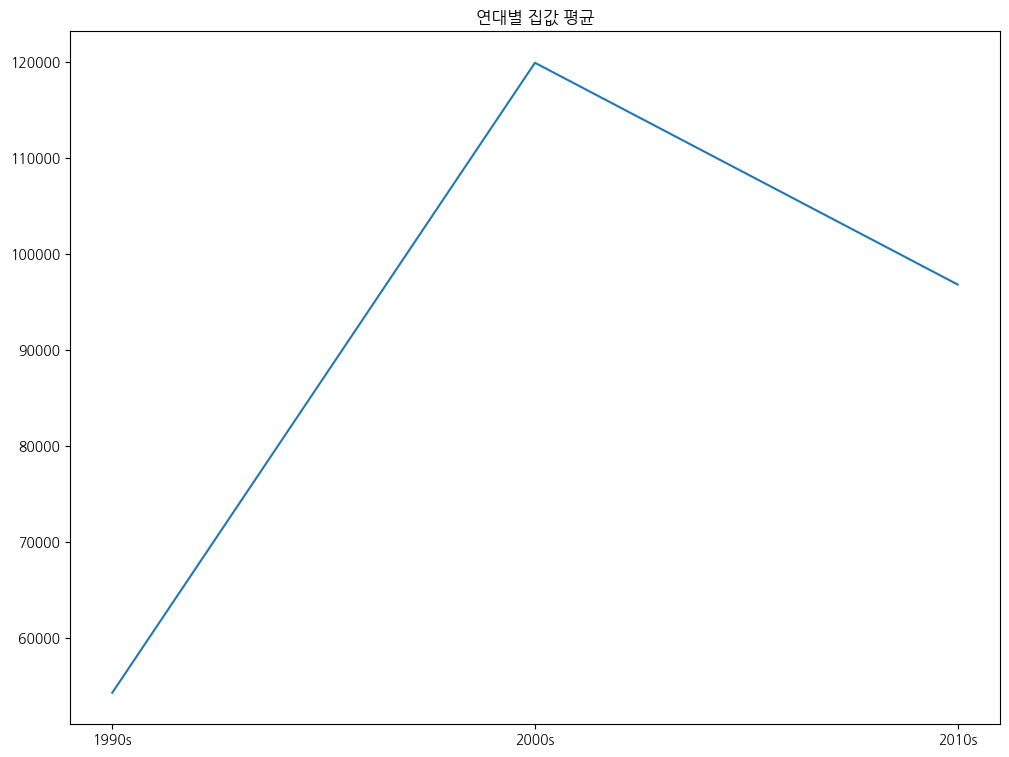

In [18]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

grouped = df_api.groupby(df_api.buildYear_grouped, observed=False)['dealAmount'].mean()
plt.figure(figsize=(12,9))
plt.title('연대별 집값 평균')
plt.plot(grouped.index, grouped.values)
plt.show()

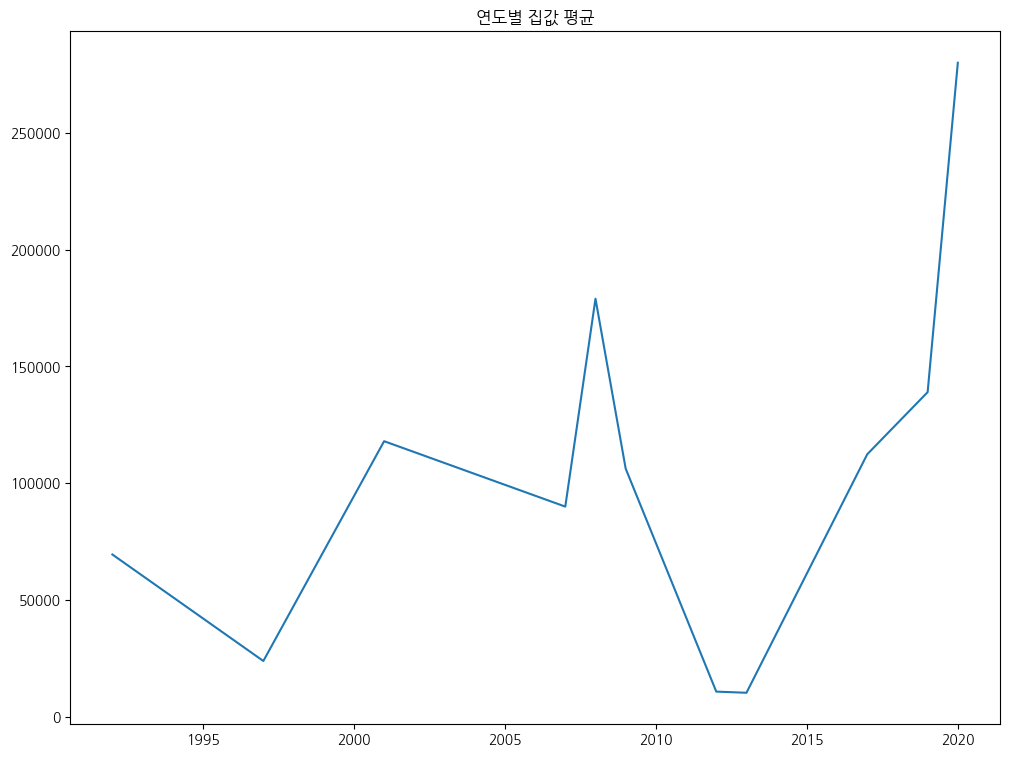

In [19]:
grouped = df_api.groupby(df_api.buildYear, observed=False)['dealAmount'].mean()
plt.figure(figsize=(12,9))
plt.title('연도별 집값 평균')
plt.plot(grouped.index, grouped.values)
plt.show()

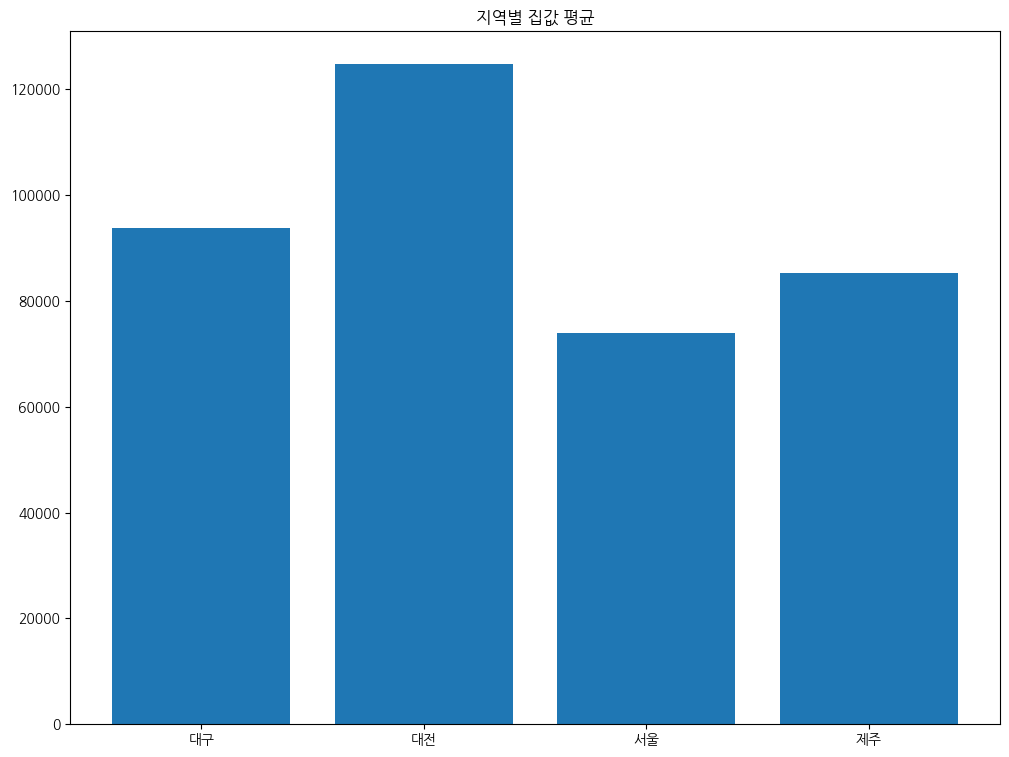

In [20]:
df_api['Location'] = df_api.filter(like='Location_').idxmax(axis=1).str.replace('Location_', '')
df_api['Location'] = df_api['Location'].fillna('서울')
grouped = df_api.groupby(df_api.Location, observed=False)['dealAmount'].mean()
plt.figure(figsize=(12,9))
plt.title('지역별 집값 평균')
plt.bar(grouped.index, grouped.values)
plt.show()

In [ ]:
df_api.columns

In [ ]:
df_api.excluUseAr.unique()

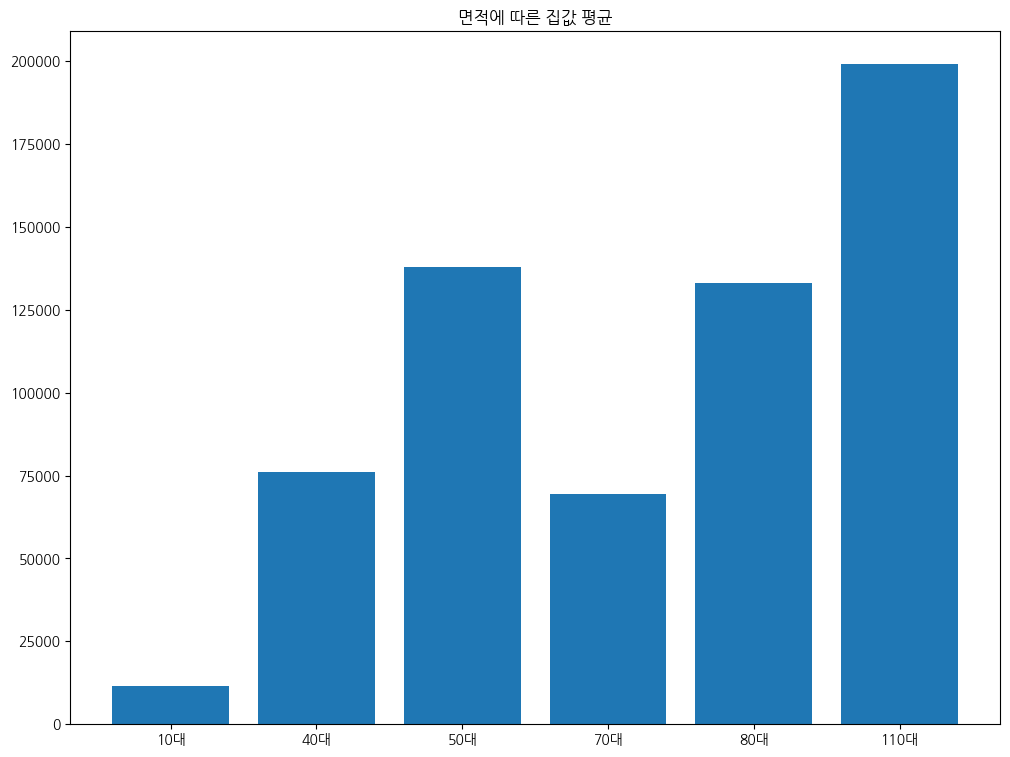

In [21]:
df_api.excluUseAr = pd.to_numeric(df_api.excluUseAr)
bins=np.arange(10,160,10)
labels= [f"{i}대" for i in bins[:-1]] 
면적_grouped = pd.cut(df_api.excluUseAr, bins=bins, labels=labels )
grouped = df_api.groupby(면적_grouped, observed=True)['dealAmount'].mean()
plt.figure(figsize=(12,9))
plt.title('면적에 따른 집값 평균')
plt.bar(grouped.index.astype(str), grouped.values)
plt.show()

In [ ]:
df_api.floor.max()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (6,) and arg 1 with shape (10,).

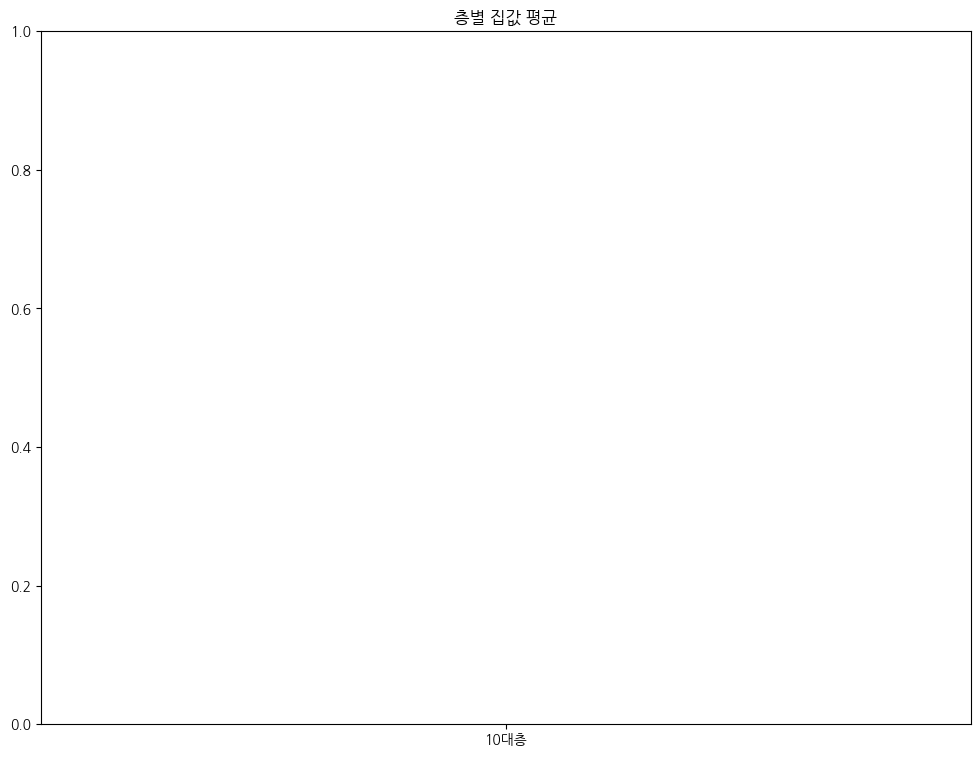

In [22]:
labels= [f"{i}층" for i in grouped.index]
grouped = df_api.groupby(df_api.floor, observed=True)['dealAmount'].mean()
plt.figure(figsize=(12,9))
plt.title('층별 집값 평균')
plt.bar(labels, grouped.values)
plt.show()